In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Adult Income 데이터셋 로드
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

In [ ]:
df = pd.read_csv(
    url,
    names=columns,
    na_values=' ?',
    skipinitialspace=True
)

print(f"데이터 shape: {df.shape}")
print(f"\n결측치 확인:\n{df.isnull().sum()}")

# 결측치 제거
df = df.dropna()

print(f"\n결측치 제거 후 shape: {df.shape}")
print(f"\n타겟 분포:\n{df['income'].value_counts()}")

데이터 shape: (32561, 15)

결측치 확인:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

결측치 제거 후 shape: (32561, 15)

타겟 분포:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [ ]:
# 수치형 특성 + 성별 (Male=1, Female=0)
numeric_features = [
    'age', 'education-num', 'capital-gain',
    'capital-loss', 'hours-per-week'
]
df['sex_encoded'] = (df['sex'] == 'Male').astype(int)
numeric_features.append('sex_encoded')

X = df[numeric_features].copy()
y = (df['income'] == '>50K').astype(int)  # >50K: 1, <=50K: 0

print("\n특성 정보:")
print(X.describe())
print(f"\n타겟 분포: {y.value_counts().to_dict()}")


특성 정보:
                age  education-num  capital-gain  capital-loss  \
count  32561.000000   32561.000000  32561.000000  32561.000000   
mean      38.581647      10.080679   1077.648844     87.303830   
std       13.640433       2.572720   7385.292085    402.960219   
min       17.000000       1.000000      0.000000      0.000000   
25%       28.000000       9.000000      0.000000      0.000000   
50%       37.000000      10.000000      0.000000      0.000000   
75%       48.000000      12.000000      0.000000      0.000000   
max       90.000000      16.000000  99999.000000   4356.000000   

       hours-per-week   sex_encoded  
count    32561.000000  32561.000000  
mean        40.437456      0.669205  
std         12.347429      0.470506  
min          1.000000      0.000000  
25%         40.000000      0.000000  
50%         40.000000      1.000000  
75%         45.000000      1.000000  
max         99.000000      1.000000  

타겟 분포: {0: 24720, 1: 7841}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train 타겟 분포: {y_train.value_counts().to_dict()}")
print(f"Test 타겟 분포:  {y_test.value_counts().to_dict()}")

Train set: (26048, 6), Test set: (6513, 6)
Train 타겟 분포: {0: 19775, 1: 6273}
Test 타겟 분포:  {0: 4945, 1: 1568}


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("스케일링 전후 비교 (첫 번째 샘플):")
print(f"스케일링 전: {X_train.iloc[0].values}")
print(f"스케일링 후: {X_train_scaled[0]}")
print(f"\n평균 (train scaled): {X_train_scaled.mean(axis=0)}")
print(f"표준편차 (train scaled): {X_train_scaled.std(axis=0)}")

스케일링 전후 비교 (첫 번째 샘플):
스케일링 전: [32 13  0  0 45  1]
스케일링 후: [-0.48306519  1.13054018 -0.14531872 -0.21736176  0.36394747  0.70285582]

평균 (train scaled): [-1.16682530e-16  3.23110362e-16 -1.69124883e-17 -1.75944435e-17
 -1.15591402e-16  2.25045208e-17]
표준편차 (train scaled): [1. 1. 1. 1. 1. 1.]


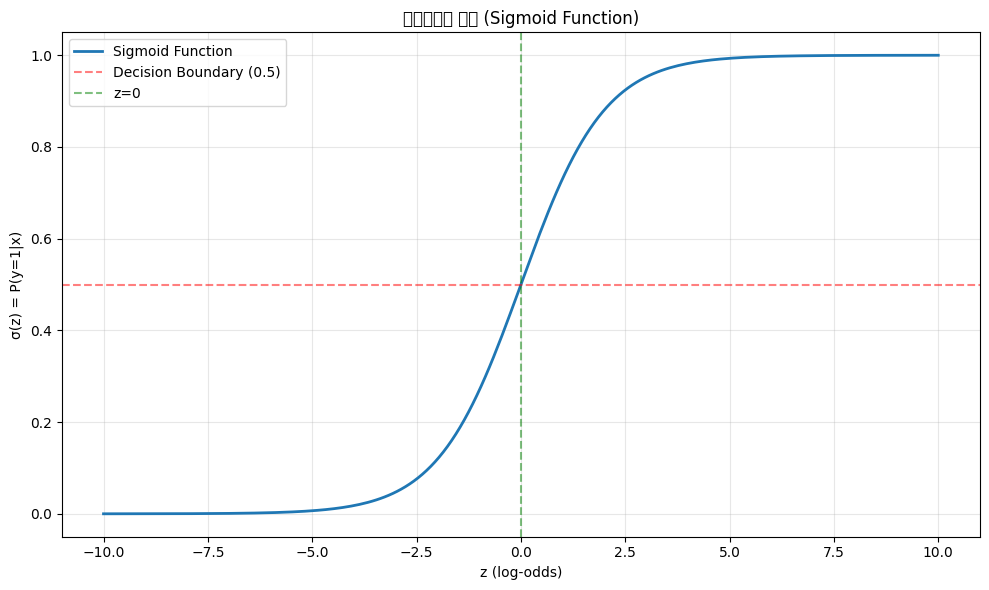

시그모이드 함수 특성:
σ(-5) = 0.006693
σ(0)  = 0.500000
σ(5)  = 0.993307


In [ ]:
def sigmoid(z):
    """시그모이드 함수: 1 / (1 + e^(-z))"""
    return 1 / (1 + np.exp(-z))

# 시그모이드 함수 시각화
z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_values, linewidth=2, label='Sigmoid Function')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision Boundary (0.5)')
plt.axvline(x=0, color='g', linestyle='--', alpha=0.5, label='z=0')
plt.xlabel('z (log-odds)')
plt.ylabel('σ(z) = P(y=1|x)')
plt.title('시그모이드 함수 (Sigmoid Function)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("시그모이드 함수 특성:")
print(f"σ(-5) = {sigmoid(-5):.6f}")
print(f"σ(0)  = {sigmoid(0):.6f}")
print(f"σ(5)  = {sigmoid(5):.6f}")

In [ ]:
base_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
base_model.fit(X_train_scaled, y_train)

print("기본 모델 하이퍼파라미터:")
print(f"C (규제 강도): {base_model.C}")
print(f"penalty:        {base_model.penalty}")
print(f"solver:         {base_model.solver}")

print("\n모델 계수 (Coefficients):")
for feature, coef in zip(numeric_features, base_model.coef_[0]):
    print(f"  {feature:20s}: {coef:8.4f}")
print(f"  {'절편 (Intercept)':20s}: {base_model.intercept_[0]:8.4f}")

기본 모델 하이퍼파라미터:
C (규제 강도): 1.0
penalty:        l2
solver:         lbfgs

모델 계수 (Coefficients):
  age                 :   0.5705
  education-num       :   0.8589
  capital-gain        :   2.2425
  capital-loss        :   0.2642
  hours-per-week      :   0.4097
  sex_encoded         :   0.5580
  절편 (Intercept)      :  -1.4392


기본 모델 성능:
Accuracy:  0.8242
Precision: 0.7196
Recall:    0.4420
F1-Score:  0.5476
ROC-AUC:   0.8510

Confusion Matrix (수치):
[[4675  270]
 [ 875  693]]


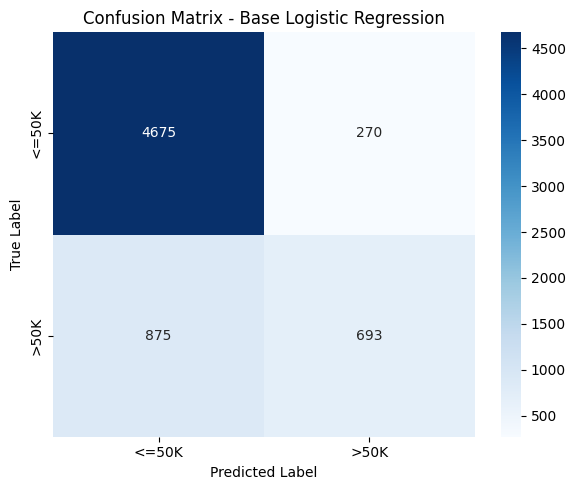

In [ ]:
y_pred = base_model.predict(X_test_scaled)
y_pred_proba = base_model.predict_proba(X_test_scaled)

print("기본 모델 성능:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (수치):")
print(cm)

# Confusion Matrix Heatmap (seaborn)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['<=50K', '>50K'],
    yticklabels=['<=50K', '>50K']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Base Logistic Regression')
plt.tight_layout()
plt.show()

처음 10개 샘플의 예측 확률:
 실제값  예측값  P(<=50K)  P(>50K)
   0    1  0.448919 0.551081
   0    0  0.904655 0.095345
   1    1  0.014461 0.985539
   1    0  0.649922 0.350078
   0    0  0.889805 0.110195
   0    0  0.983305 0.016695
   0    0  0.944748 0.055252
   0    1  0.238248 0.761752
   0    0  0.768468 0.231532
   0    0  0.561048 0.438952


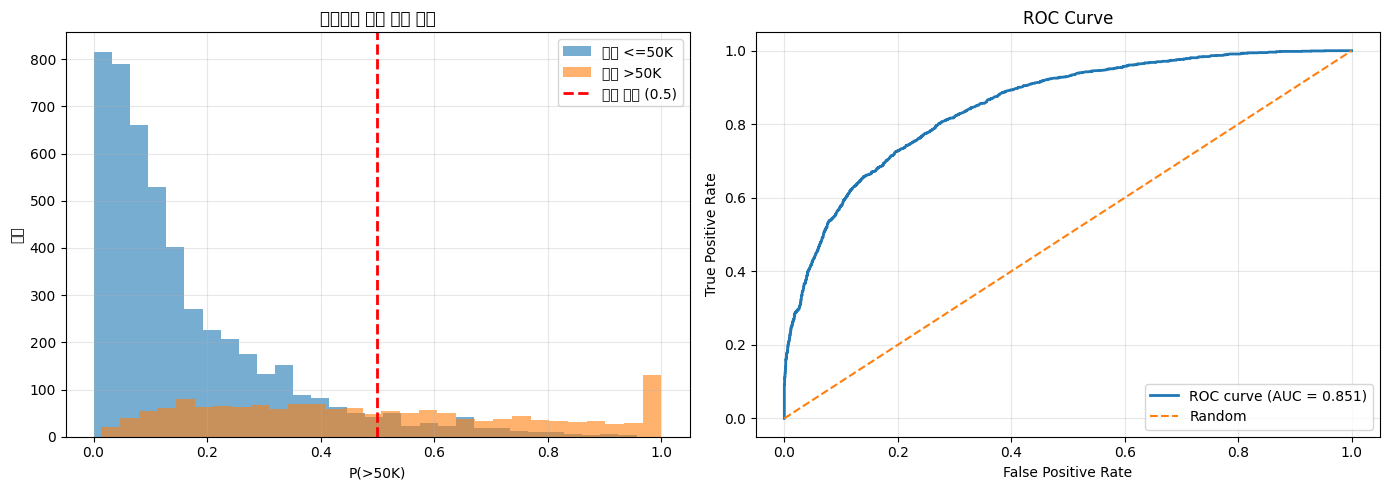

In [ ]:
print("처음 10개 샘플의 예측 확률:")
prob_df = pd.DataFrame({
    '실제값': y_test.values[:10],
    '예측값': y_pred[:10],
    'P(<=50K)': y_pred_proba[:10, 0],
    'P(>50K)': y_pred_proba[:10, 1]
})
print(prob_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for class_label in [0, 1]:
    mask = (y_test == class_label)
    axes[0].hist(
        y_pred_proba[mask, 1],
        bins=30,
        alpha=0.6,
        label=f'실제 {["<=50K", ">50K"][class_label]}'
    )
axes[0].axvline(x=0.5, color='r', linestyle='--', linewidth=2, label='결정 경계 (0.5)')
axes[0].set_xlabel('P(>50K)')
axes[0].set_ylabel('빈도')
axes[0].set_title('클래스별 예측 확률 분포')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
sample_idx = 0
sample = X_test_scaled[sample_idx].reshape(1, -1)
log_odds = base_model.decision_function(sample)[0]
probability = base_model.predict_proba(sample)[0, 1]

print(f"샘플 {sample_idx}:")
print(f"  Log-odds (z): {log_odds:.4f}")
print(f"  확률 P(y=1):  {probability:.4f}")
print(f"  검증: σ(z)     = {sigmoid(log_odds):.4f}")

print("\n로그 오즈 해석:")
odds = np.exp(log_odds)
print(f"  z = {log_odds:.4f} → odds = e^z = {odds:.4f}")
if log_odds > 0:
    print(f"  → 양성 클래스(>50K)일 오즈가 음성보다 {odds:.2f}배 더 큼")
else:
    print(f"  → 음성 클래스(<=50K)일 오즈가 양성보다 {np.exp(-log_odds):.2f}배 더 큼")

샘플 0:
  Log-odds (z): 0.2050
  확률 P(y=1):  0.5511
  검증: σ(z)     = 0.5511

로그 오즈 해석:
  z = 0.2050 → odds = e^z = 1.2276
  → 양성 클래스(>50K)일 오즈가 음성보다 1.23배 더 큼


In [ ]:
print("\n각 특성의 오즈비(Odds Ratio) = e^β:")
for feature, coef in zip(numeric_features, base_model.coef_[0]):
    odds_ratio = np.exp(coef)
    print(f"  {feature:20s}: β={coef:7.4f}, e^β={odds_ratio:7.4f}")
    if coef > 0:
        print(f"    → {feature} 1 표준편차 증가 시, >50K 오즈가 {odds_ratio:.2f}배 증가")
    else:
        print(f"    → {feature} 1 표준편차 증가 시, >50K 오즈가 {1/odds_ratio:.2f}배 감소")


각 특성의 오즈비(Odds Ratio) = e^β:
  age                 : β= 0.5705, e^β= 1.7691
    → age 1 표준편차 증가 시, >50K 오즈가 1.77배 증가
  education-num       : β= 0.8589, e^β= 2.3606
    → education-num 1 표준편차 증가 시, >50K 오즈가 2.36배 증가
  capital-gain        : β= 2.2425, e^β= 9.4172
    → capital-gain 1 표준편차 증가 시, >50K 오즈가 9.42배 증가
  capital-loss        : β= 0.2642, e^β= 1.3024
    → capital-loss 1 표준편차 증가 시, >50K 오즈가 1.30배 증가
  hours-per-week      : β= 0.4097, e^β= 1.5064
    → hours-per-week 1 표준편차 증가 시, >50K 오즈가 1.51배 증가
  sex_encoded         : β= 0.5580, e^β= 1.7472
    → sex_encoded 1 표준편차 증가 시, >50K 오즈가 1.75배 증가



특성 'age' 변화에 따른 확률 변화:
  기준 확률:       0.5511 (55.11%)
  +1 std 후 확률:  0.6847 (68.47%)
  확률 변화량:     +0.1336 (+13.36%p)


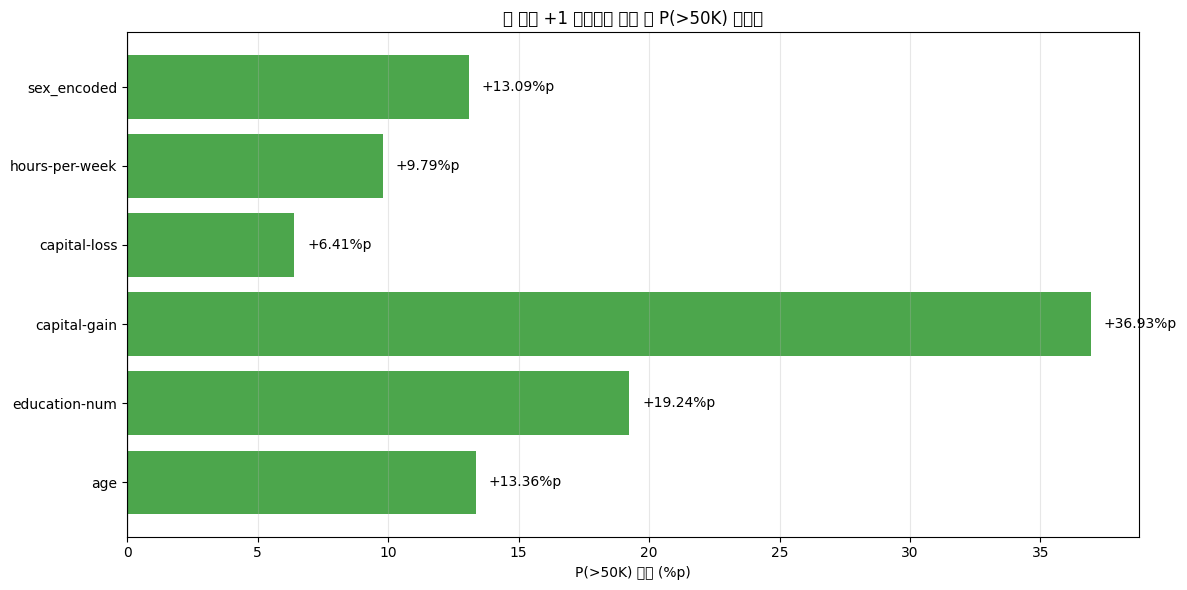

In [ ]:
# 기준 샘플
base_sample = X_test_scaled[0:1].copy()
base_prob = base_model.predict_proba(base_sample)[0, 1]

feature_idx = 0  # age 기준
feature_name = numeric_features[feature_idx]

modified_sample = base_sample.copy()
modified_sample[0, feature_idx] += 1  # +1 std
modified_prob = base_model.predict_proba(modified_sample)[0, 1]

prob_change = modified_prob - base_prob
prob_change_pct = prob_change * 100

print(f"\n특성 '{feature_name}' 변화에 따른 확률 변화:")
print(f"  기준 확률:       {base_prob:.4f} ({base_prob * 100:.2f}%)")
print(f"  +1 std 후 확률:  {modified_prob:.4f} ({modified_prob * 100:.2f}%)")
print(f"  확률 변화량:     {prob_change:+.4f} ({prob_change_pct:+.2f}%p)")

# 여러 특성에 대한 확률 변화 시각화
fig, ax = plt.subplots(figsize=(12, 6))

prob_changes = []
for i, feature in enumerate(numeric_features):
    modified_sample = base_sample.copy()
    modified_sample[0, i] += 1
    new_prob = base_model.predict_proba(modified_sample)[0, 1]
    prob_changes.append((new_prob - base_prob) * 100)

colors = ['green' if x > 0 else 'red' for x in prob_changes]
bars = ax.barh(numeric_features, prob_changes, alpha=0.7, color=colors)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('P(>50K) 변화 (%p)')
ax.set_title('각 특성 +1 표준편차 변화 시 P(>50K) 변화량')
ax.grid(True, alpha=0.3, axis='x')

for bar, value in zip(bars, prob_changes):
    x_pos = value + (0.5 if value > 0 else -0.5)
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f'{value:+.2f}%p',
        va='center',
    )

plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']  # 둘 다 l1, l2 지원
}

print("그리드 서치 파라미터:")
print(param_grid)

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\n그리드 서치 실행 중...")
grid_search.fit(X_train_scaled, y_train)

print("\n최적 하이퍼파라미터:")
print(grid_search.best_params_)
print(f"\n최적 CV ROC-AUC 스코어: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df.nsmallest(5, 'rank_test_score')[
    ['param_C', 'param_penalty', 'param_solver', 'mean_test_score', 'rank_test_score']
]
print("\n상위 5개 하이퍼파라미터 조합:")
print(top_results.to_string(index=False))

그리드 서치 파라미터:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}

그리드 서치 실행 중...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

최적 하이퍼파라미터:
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

최적 CV ROC-AUC 스코어: 0.8448

상위 5개 하이퍼파라미터 조합:
 param_C param_penalty param_solver  mean_test_score  rank_test_score
     0.1            l2    liblinear         0.844751                1
     0.1            l1    liblinear         0.844750                2
     0.1            l1         saga         0.844749                3
     1.0            l2         saga         0.844748                4
     1.0            l2    liblinear         0.844746                5


In [ ]:
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)

metrics_comparison = pd.DataFrame({
    '지표': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    '기본 모델': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_proba[:, 1])
    ],
    '최적 모델': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        roc_auc_score(y_test, y_pred_proba_best[:, 1])
    ]
})
metrics_comparison['개선율(%)'] = (
    (metrics_comparison['최적 모델'] - metrics_comparison['기본 모델'])
    / metrics_comparison['기본 모델'] * 100
)

print(metrics_comparison.to_string(index=False))

print("\n최적 모델 계수:")
for feature, coef in zip(numeric_features, best_model.coef_[0]):
    print(f"  {feature:20s}: {coef:8.4f}")
print(f"  {'절편 (Intercept)':20s}: {best_model.intercept_[0]:8.4f}")

       지표    기본 모델    최적 모델   개선율(%)
 Accuracy 0.824198 0.824505 0.037258
Precision 0.719626 0.720665 0.144300
   Recall 0.441964 0.442602 0.144300
 F1-Score 0.547610 0.548400 0.144300
  ROC-AUC 0.851007 0.851013 0.000743

최적 모델 계수:
  age                 :   0.5668
  education-num       :   0.8521
  capital-gain        :   2.1296
  capital-loss        :   0.2623
  hours-per-week      :   0.4068
  sex_encoded         :   0.5523
  절편 (Intercept)      :  -1.4391



결정 경계 시각화에 사용할 특성: ['capital-gain', 'education-num']
계수 절댓값: [2.24253718 0.85892333]


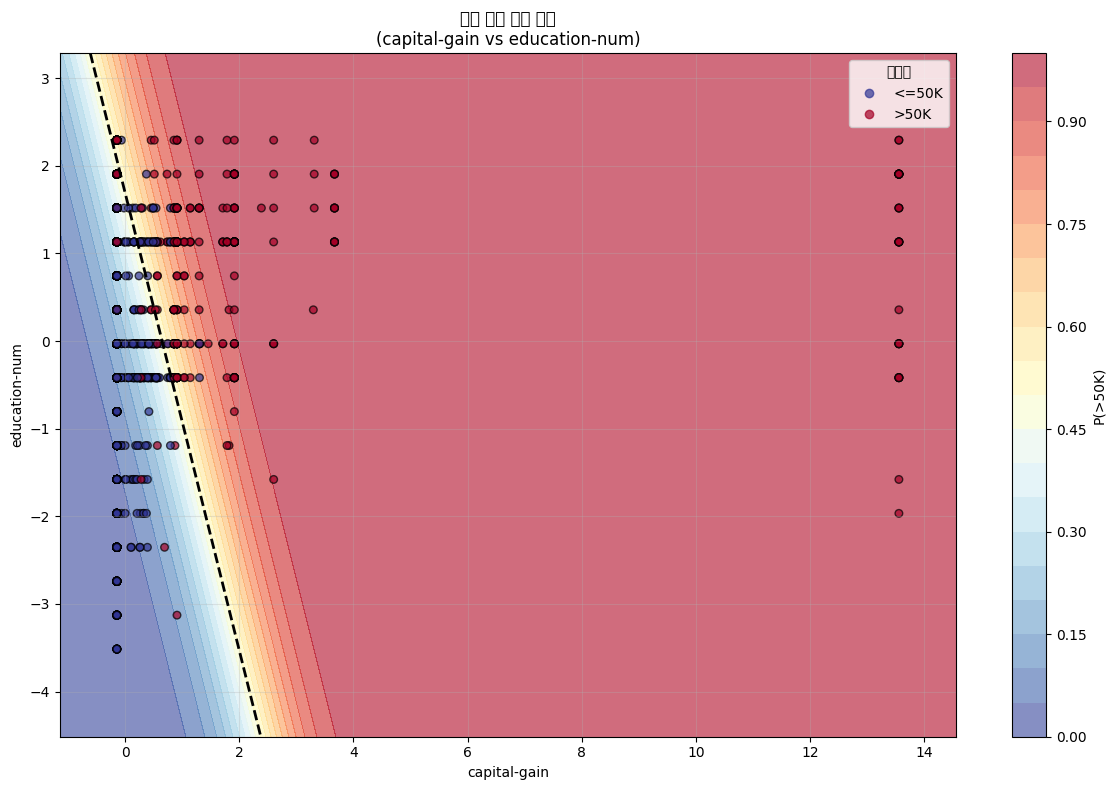

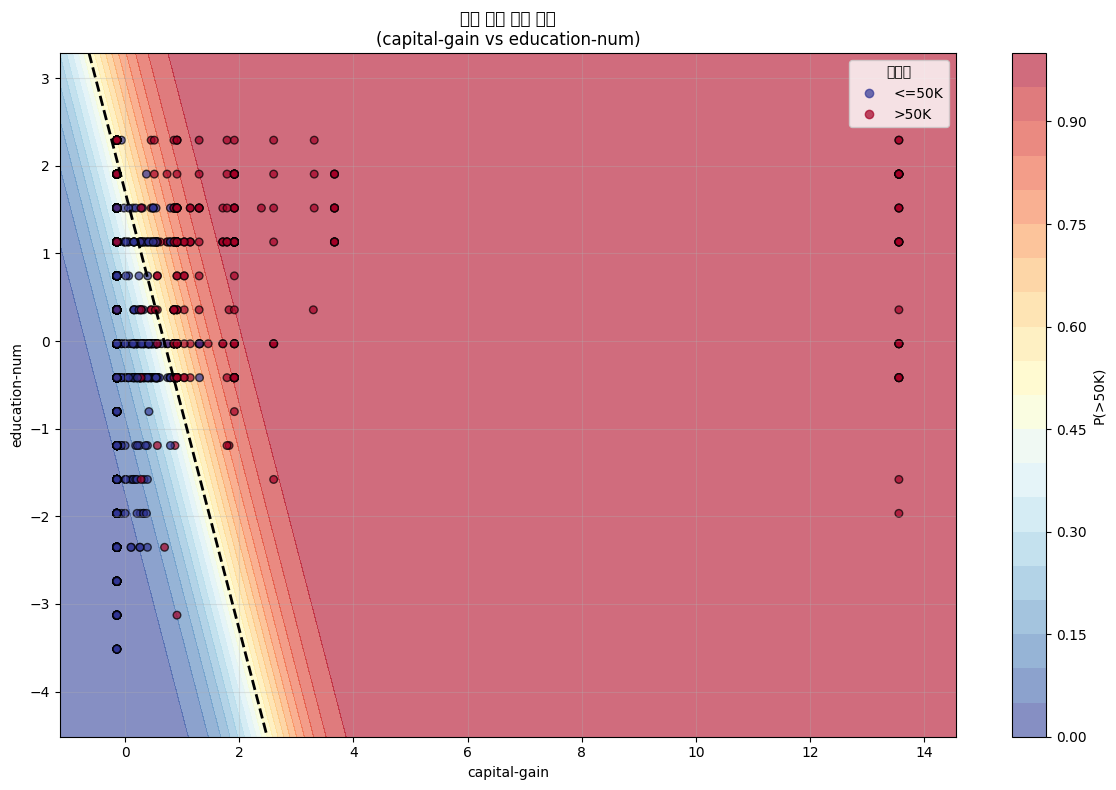

In [ ]:
def plot_decision_boundary_2d(model, X_scaled, y_array,
                              feature_indices, feature_names,
                              title, filename):
    """2D 결정 경계 시각화 (다른 특성은 평균으로 고정)"""
    X_2d = X_scaled[:, feature_indices]

    h = 0.02
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # 전체 차원 만들고 나머지는 평균값으로 채우기
    mesh_samples = np.zeros((xx.ravel().shape[0], X_scaled.shape[1]))
    mesh_samples[:] = X_scaled.mean(axis=0)
    mesh_samples[:, feature_indices[0]] = xx.ravel()
    mesh_samples[:, feature_indices[1]] = yy.ravel()

    Z = model.predict_proba(mesh_samples)[:, 1]
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(12, 8))
    contour = plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.6)
    plt.colorbar(contour, label='P(>50K)')

    # 결정 경계선 (P=0.5)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black',
                linewidths=2, linestyles='--')

    scatter = plt.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=y_array,
        cmap='RdYlBu_r',
        edgecolors='black',
        s=30,
        alpha=0.7
    )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)

    handles, _ = scatter.legend_elements()
    plt.legend(
        handles,
        ['<=50K', '>50K'],
        title='클래스',
        loc='best'
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# 계수 절댓값 기준 상위 2개 특성 선택
feature_importance = np.abs(base_model.coef_[0])
top_2_indices = np.argsort(feature_importance)[-2:][::-1]
top_2_features = [numeric_features[i] for i in top_2_indices]

print(f"\n결정 경계 시각화에 사용할 특성: {top_2_features}")
print(f"계수 절댓값: {feature_importance[top_2_indices]}")

# 기본 모델 결정 경계
plot_decision_boundary_2d(
    base_model, X_test_scaled, y_test.values,
    top_2_indices, top_2_features,
    f'기본 모델 결정 경계\n({top_2_features[0]} vs {top_2_features[1]})',
    'decision_boundary_base.png'
)

# 최적 모델 결정 경계
plot_decision_boundary_2d(
    best_model, X_test_scaled, y_test.values,
    top_2_indices, top_2_features,
    f'최적 모델 결정 경계\n({top_2_features[0]} vs {top_2_features[1]})',
    'decision_boundary_best.png'
)

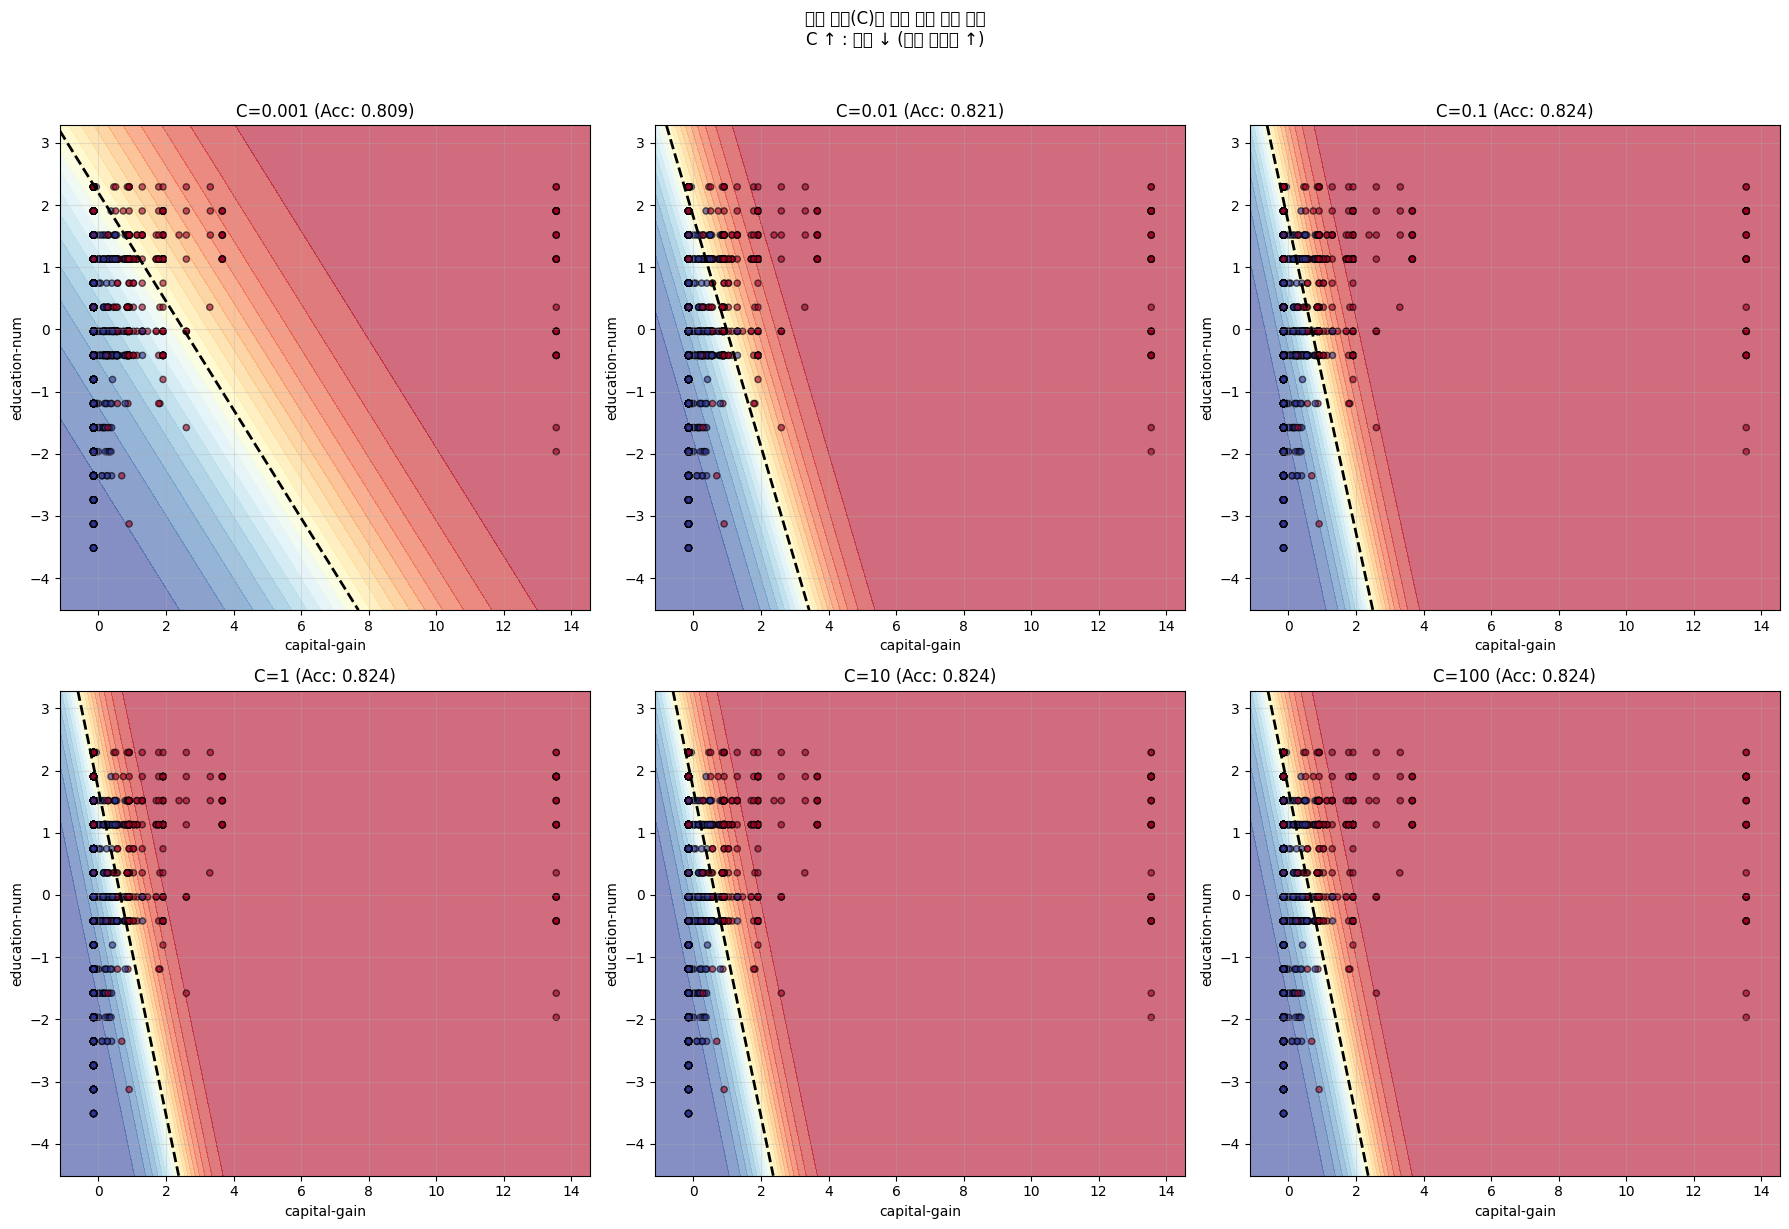


[L1 vs L2 규제 비교]
--------------------------------------------------


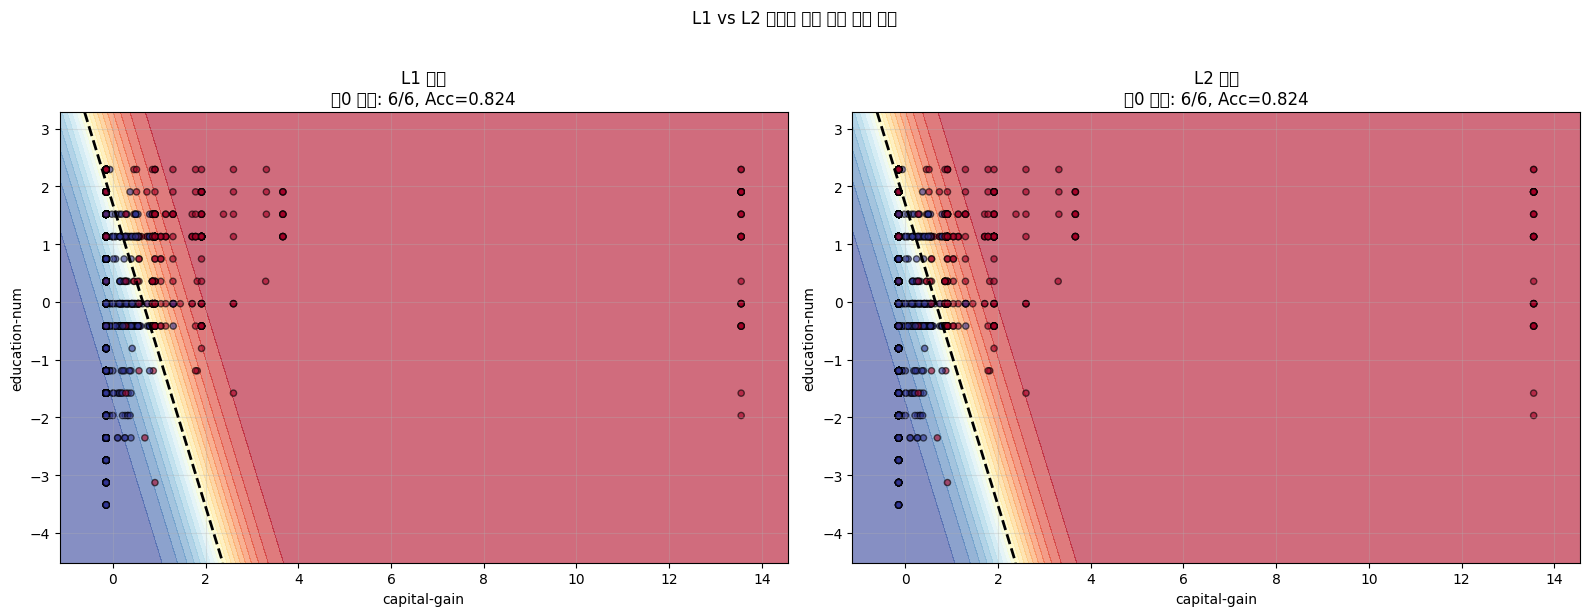

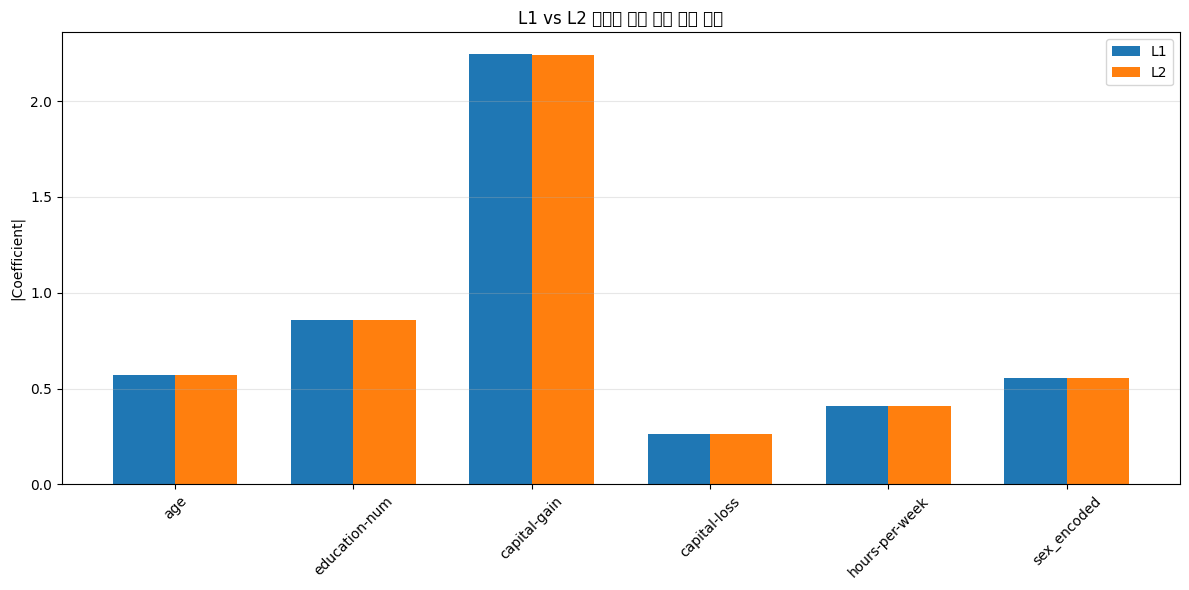


L1 vs L2 규제 계수 해석:
age                  | L1:   0.5701 | L2:   0.5703 | |L1|<0.5703 → L1가 더 희소(sparse)해지는 경향
education-num        | L1:   0.8586 | L2:   0.8586 | |L1|<0.8586 → L1가 더 희소(sparse)해지는 경향
capital-gain         | L1:   2.2463 | L2:   2.2386 | |L1|<2.2386 → L1가 더 희소(sparse)해지는 경향
capital-loss         | L1:   0.2645 | L2:   0.2646 | |L1|<0.2646 → L1가 더 희소(sparse)해지는 경향
hours-per-week       | L1:   0.4091 | L2:   0.4093 | |L1|<0.4093 → L1가 더 희소(sparse)해지는 경향
sex_encoded          | L1:   0.5574 | L2:   0.5575 | |L1|<0.5575 → L1가 더 희소(sparse)해지는 경향


In [ ]:
# C 값 6개
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

X_2d = X_test_scaled[:, top_2_indices]

for idx, C_val in enumerate(C_values):
    model = LogisticRegression(
        C=C_val,
        random_state=42,
        max_iter=1000
    )
    model.fit(X_train_scaled, y_train)

    h = 0.05
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    mesh_samples = np.zeros((xx.ravel().shape[0], X_test_scaled.shape[1]))
    mesh_samples[:] = X_test_scaled.mean(axis=0)
    mesh_samples[:, top_2_indices[0]] = xx.ravel()
    mesh_samples[:, top_2_indices[1]] = yy.ravel()

    Z = model.predict_proba(mesh_samples)[:, 1]
    Z = Z.reshape(xx.shape)

    ax = axes[idx]
    contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black',
               linewidths=2, linestyles='--')

    ax.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=y_test.values,
        cmap='RdYlBu_r',
        edgecolors='black',
        s=20,
        alpha=0.6
    )

    y_pred_c = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_c)

    ax.set_title(f'C={C_val} (Acc: {acc:.3f})')
    ax.set_xlabel(top_2_features[0])
    ax.set_ylabel(top_2_features[1])
    ax.grid(True, alpha=0.3)

plt.suptitle(
    '규제 강도(C)에 따른 결정 경계 변화\nC ↑ : 규제 ↓ (모델 복잡도 ↑)',
    y=1.02
)
plt.tight_layout()
plt.show()

print("\n[L1 vs L2 규제 비교]")
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
l1_model = None
l2_model = None

for idx, penalty in enumerate(['l1', 'l2']):
    model = LogisticRegression(
        C=1.0,
        penalty=penalty,
        solver='saga',
        random_state=42,
        max_iter=2000
    )
    model.fit(X_train_scaled, y_train)

    if penalty == 'l1':
        l1_model = model
    else:
        l2_model = model

    X_2d = X_test_scaled[:, top_2_indices]

    h = 0.05
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    mesh_samples = np.zeros((xx.ravel().shape[0], X_test_scaled.shape[1]))
    mesh_samples[:] = X_test_scaled.mean(axis=0)
    mesh_samples[:, top_2_indices[0]] = xx.ravel()
    mesh_samples[:, top_2_indices[1]] = yy.ravel()

    Z = model.predict_proba(mesh_samples)[:, 1]
    Z = Z.reshape(xx.shape)

    ax = axes[idx]
    contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black',
               linewidths=2, linestyles='--')

    ax.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=y_test.values,
        cmap='RdYlBu_r',
        edgecolors='black',
        s=20,
        alpha=0.6
    )

    coef = model.coef_[0]
    non_zero = np.sum(np.abs(coef) > 1e-4)
    acc_pen = accuracy_score(y_test, model.predict(X_test_scaled))

    ax.set_title(
        f'{penalty.upper()} 규제\n비0 계수: {non_zero}/{len(coef)}, Acc={acc_pen:.3f}',
    )
    ax.set_xlabel(top_2_features[0])
    ax.set_ylabel(top_2_features[1])
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'L1 vs L2 규제에 따른 결정 경계 비교',
    y=1.02
)
plt.tight_layout()
plt.show()

# L1 vs L2 계수 크기 비교 바 플롯
plt.figure(figsize=(12, 6))
indices = np.arange(len(numeric_features))
width = 0.35

plt.bar(
    indices - width / 2,
    np.abs(l1_model.coef_[0]),
    width,
    label='L1'
)
plt.bar(
    indices + width / 2,
    np.abs(l2_model.coef_[0]),
    width,
    label='L2'
)

plt.xticks(indices, numeric_features, rotation=45)
plt.ylabel('|Coefficient|')
plt.title('L1 vs L2 규제에 따른 계수 크기 비교')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nL1 vs L2 규제 계수 해석:")
for feature, c1, c2 in zip(
    numeric_features,
    l1_model.coef_[0],
    l2_model.coef_[0]
):
    print(
        f"{feature:20s} | L1: {c1:8.4f} | L2: {c2:8.4f} "
    )